In [5]:

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from data_models import MixtureClassificationModel,TeacherStudentModel, exponential_covariance,create_downsampling_matrix,MNISTDataModel
from losses_regularizers import LogisticLoss, QuadraticRegularizer, PseudoHuberRegularizer,SquaredLoss,HingeLoss
from erm_theory import ERMTrainer, TheoryFixedPointSolver

rng = np.random.default_rng(0)
rng2 = np.random.default_rng(1)

c = 5
n = c * 7
p = c * 30

K = 2
gamma = np.array([0.2, 0.8], dtype=float)

mu1 = np.zeros(p); mu1[0] = 3
mu2 = np.zeros(p); mu2[0] = -2
mus = [mu1, mu2]
C = exponential_covariance(p, rho=0.5)
C2_seed = np.random.randn(p,p)/np.sqrt(p)
C2 = C2_seed @ C2_seed.T + 0.1*np.eye(p)

covs = [C, C]

# For binary logistic loss, use labels in {+1, -1}
y_values = [+1.0, -1.0]


model = MixtureClassificationModel(
    p=p,
    gamma=gamma,
    mus=mus,
    covs=covs,
    y_values=y_values,
    feature_dist="gaussian",
)

loss = LogisticLoss(max_iter=60, tol=1e-10)
# loss = HingeLoss()







In [6]:
y_values = [0,1,2]
rng = np.random.default_rng(0)

# W = np.eye(784)[rng.choice(784, size=int(p), replace=False),:]
# W = exponential_covariance(p, rho=0.01)@W
m = 10
W_downsample = create_downsampling_matrix(m)
model = MNISTDataModel(
    data_path="mnist.npz",
    split="test",
    stats_split="train",
    noise_std=0.4,
    # representation= "raw",
    representation= "random_features",
    classes=[0,1,2,3,4,5,6,7,8,9],
    task="multiclass",
    W=W_downsample,
    # positive_classes=[0],
    # activation = 'identity',
    activation = 'tanh',
)
loss = LogisticLoss(max_iter=600, tol=1e-10)


Original shape: (784,)
Matrix W shape: (100, 784)


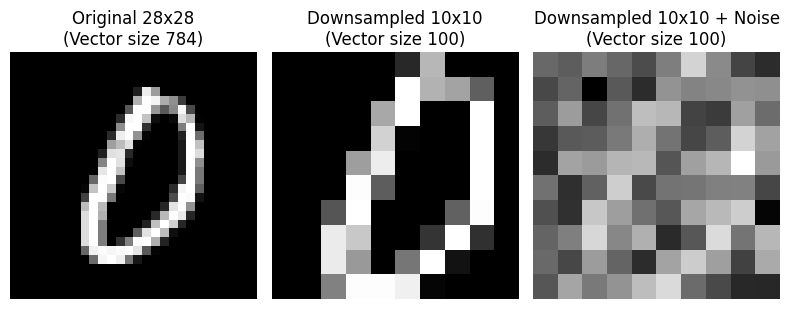

In [7]:
model_raw = MNISTDataModel(
    data_path="mnist.npz",
    split="test",
    stats_split="train",
    noise_std=0,
    representation= "raw",
    classes=[0],
    task="multiclass",
)


# 1. Load a sample image
p = model.class_params()['p']
m = int(np.sqrt(p))
x_flat = model_raw.sample_class(0,1)[0].reshape(784,)
x_modif = model.transform(x_flat.reshape(1,784)).reshape(m*m,)
x_modif_noise = model._add_noise(x_modif, rng)
img_original = x_flat.reshape(28,28)  # Shape (28, 28)

print(f"Original shape: {x_flat.shape}")
print(f"Matrix W shape: {W_downsample.shape}")

# 3. Apply the transformation: y = W_downsamplex
img_small = x_modif.reshape(m, m)
img_small_noise = x_modif_noise.reshape(m, m)

# 4. Visualize
plt.figure(figsize=(8, 4))

plt.subplot(1, 3, 1)
plt.title(f"Original 28x28\n(Vector size 784)")
plt.imshow(img_original, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"Downsampled {m}x{m}\n(Vector size {m*m})")
plt.imshow(img_small, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"Downsampled {m}x{m} + Noise\n(Vector size {m*m})")
plt.imshow(img_small_noise, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
lam_min = 0.001
lam_0 = np.min([0,lam_min])
lam_max = 10
power_exp = 30
nb_points = 15
ratio_th_emp = 15
mc_samples = 6000
num_trials = 50
nb_points_th = ratio_th_emp*(nb_points-1)+1
lambdas = lam_0 + np.linspace((lam_max-lam_0)**(1/power_exp), (lam_min-lam_0)**(1/power_exp), nb_points)**(power_exp)
lambdas_th = lam_0 + np.linspace((lam_max-lam_0)**(1/power_exp), (lam_min-lam_0)**(1/power_exp), nb_points_th)**(power_exp)
n=30
mu0 = None
alpha0 = None
nu0 = None

fp_damping =0.5
fp_tol = 2e-4
fp_max_iter = 200
theory_preds = []
theory_converged = []
nu_th = []
kappa_th = []
alpha_th = []
empirical_means = []
empirical_stds = []
empirical_means_q = []
empirical_stds_q = []
for (idx,lam) in enumerate(lambdas_th):
    reg = PseudoHuberRegularizer(lam= lam,  delta = 0.5)
    # reg = QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))
    if idx%ratio_th_emp ==0:
        
        print(f"\n===== lambda = {lam:g} (empirical gen reg) =====")


        trainer = ERMTrainer(model=model, loss=loss, regularizer=reg)
        emp = trainer.run_trials(
            n_train=n,
            num_trials=num_trials,
            rng=rng,
            solver_maxiter=2000,
            tol=1e-6,
            method="L-BFGS-B",
            verbose=False,
        )
        empirical_means.append(emp["gen_loss_mean"])
        empirical_stds.append(emp["gen_loss_std"])
        print(f"Empirical gen loss: mean={emp['gen_loss_mean']:.6f}  std={emp['gen_loss_std']:.6f}")
    print(f"\n===== lambda = {lam:g} (theory) =====")
    solver = TheoryFixedPointSolver(
        model=model,
        loss=loss,
        regularizer=reg,
        n_train=n,
        mc_samples=int(mc_samples/np.min([1, lam**2/0.1])),  # more samples for smaller lambda
        rng=np.random.default_rng(123),  # fixed for repeatability
    )

    # Heuristic damping schedule: smaller λ -> smaller damping

    th = solver.solve(
        max_iter=fp_max_iter,
        tol=np.max([lam,1]) * fp_tol,
        damping=np.max([lam,1]) * fp_damping,
        verbose=False,
        mu0=mu0,
        alpha0=alpha0,
        nu0=nu0,
    )

    theory_preds.append(th["predicted_loss"])
    theory_converged.append(bool(th["converged"]))

    # Warm start for next (smaller) lambda
    mu0, alpha0, nu0 = th["mu_star"], th["alpha"], th["nu"]
    nu_th.append(th["nu"])
    kappa_th.append(th["kappa"])
    alpha_th.append(th["alpha"])
    print(f"Theory predicted loss: {th['predicted_loss']:.6f}  (converged={th['converged']}, iters={th['num_iter']}, damping_final={th.get('damping_final', float('nan')):.3f})")
    
    if idx%ratio_th_emp ==0:
        print(f"\n===== lambda = {lam:g} (empirical quadratic reg) =====")

        H_reg = reg.hessian(np.zeros(p))

        # reg_q = QuadraticRegularizer(a=reg.grad(mu0) , H=H_reg)
        reg_q = QuadraticRegularizer(a=reg.grad(mu0) - H_reg@mu0, H=H_reg)
        # reg_q = QuadraticRegularizer(a=np.zeros(p), H=reg.hessian(np.zeros(p)))
        trainer = ERMTrainer(model=model, loss=loss, regularizer=reg_q)
        emp_q = trainer.run_trials(
            n_train=n,
            num_trials=num_trials,
            rng=rng2,
            solver_maxiter=2000,
            tol=1e-6,
            method="L-BFGS-B",
            verbose=False,
        )
        empirical_means_q.append(emp_q["gen_loss_mean"])
        empirical_stds_q.append(emp_q["gen_loss_std"])
        print(f"Empirical gen loss: mean={emp_q['gen_loss_mean']:.6f}  std={emp_q['gen_loss_std']:.6f}")




# empirical_means = np.asarray(empirical_means)
# empirical_stds = np.asarray(empirical_stds)





===== lambda = 10 (empirical gen reg) =====
Empirical gen loss: mean=0.267097  std=0.219179

===== lambda = 10 (theory) =====
Theory predicted loss: 0.307161  (converged=True, iters=48, damping_final=0.722)

===== lambda = 10 (empirical quadratic reg) =====
Empirical gen loss: mean=0.224925  std=0.191334

===== lambda = 9.62916 (theory) =====
Theory predicted loss: 0.304202  (converged=True, iters=45, damping_final=0.718)

===== lambda = 9.27163 (theory) =====
Theory predicted loss: 0.301312  (converged=True, iters=43, damping_final=0.707)

===== lambda = 8.92695 (theory) =====
Theory predicted loss: 0.298447  (converged=True, iters=41, damping_final=0.697)

===== lambda = 8.59467 (theory) =====
Theory predicted loss: 0.295606  (converged=True, iters=39, damping_final=0.688)

===== lambda = 8.27436 (theory) =====
Theory predicted loss: 0.292789  (converged=True, iters=37, damping_final=0.680)

===== lambda = 7.9656 (theory) =====
Theory predicted loss: 0.289997  (converged=True, iters